In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
print('Imports done.')

Imports done.


In [2]:
# Load abstract file
BASE_PATH = './data/'
abstract_raw = pd.read_excel(BASE_PATH + 'grants-with-abstract.xlsx',
                             sheet_name='Grants with abstract (2).csv')
print(f'Raw rows: {len(abstract_raw):,}')
print(abstract_raw['Sourcetype'].value_counts())

Raw rows: 8,075
Sourcetype
Institution    4492
AA             3583
Name: count, dtype: int64


In [3]:
# Keep AA source rows only, drop rows missing abstract text
aa = abstract_raw[abstract_raw['Sourcetype'] == 'AA'].copy()
aa = aa.dropna(subset=['Abstract'])
aa['Start Date'] = pd.to_datetime(aa['Start Date'], errors='coerce')
aa['Year'] = aa['Start Date'].dt.year

print(f'AA rows with abstract text: {len(aa):,}')
print(f'Year range: {int(aa["Year"].min())} to {int(aa["Year"].max())}')
print(f'Unique PIs: {aa["PersonId"].nunique():,}')

AA rows with abstract text: 2,873
Year range: 1995 to 2026
Unique PIs: 643


In [4]:
# Build stopword list — three layers:
# 1. Standard English words (the, and, is, of, it ...)
# 2. Grant boilerplate (research, study, develop, provide ...)
# 3. Northeastern/university words (northeastern, university, program ...)
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

grant_boilerplate = {
    'research', 'study', 'project', 'award', 'grant', 'proposal', 'funded',
    'funding', 'investigator', 'principal', 'collaborative', 'collaboration',
    'work', 'working', 'workers', 'university', 'northeastern', 'national',
    'science', 'foundation', 'center', 'institute', 'program', 'programs',
    'support', 'supported', 'faculty', 'student', 'students', 'education',
    'educational', 'laboratory', 'lab', 'develop', 'development', 'developed',
    'developing', 'provide', 'provided', 'provides', 'providing', 'include',
    'including', 'includes', 'included', 'approach', 'approaches', 'propose',
    'proposed', 'novel', 'new', 'use', 'used', 'using', 'uses', 'based',
    'focus', 'result', 'results', 'resulting', 'aim', 'aims', 'goal', 'goals',
    'important', 'significant', 'key', 'critical', 'potential', 'ability',
    'enable', 'enabled', 'demonstrate', 'understand', 'understanding',
    'investigate', 'investigation', 'require', 'required', 'design', 'designs',
    'implement', 'implementation', 'explore', 'consider', 'address', 'advance',
    'advances', 'advanced', 'high', 'large', 'small', 'specific', 'general',
    'current', 'al', 'et', 'eg', 'ie', 'vs', 'ii', 'iii', 'co', 'pi',
}

all_stops = list(ENGLISH_STOP_WORDS.union(grant_boilerplate))
print(f'Total stopwords: {len(all_stops)}')

Total stopwords: 419


In [5]:
# Clean text: lowercase, remove numbers, punctuation, short words
# Combine title + abstract for richer signal
def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'https?://\S+', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'-', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\b\w{1,2}\b', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

aa['full_text']  = aa['Title'].fillna('') + ' ' + aa['Abstract'].fillna('')
aa['clean_text'] = aa['full_text'].apply(clean_text)

print('Cleaning done.')
print('\nOriginal:')
print(aa['Abstract'].iloc[0][:200])
print('\nCleaned:')
print(aa['clean_text'].iloc[0][:200])

Cleaning done.

Original:
Secure multi-party computation (MPC) allows several mutually untrusting parties to perform joint computations while keeping their inputs private. This project develops new techniques for constructing 

Cleaned:
twc small collaborative iterative approach secure computation secure multi party computation mpc allows several mutually untrusting parties perform joint computations while keeping their inputs privat


In [6]:
# Check most frequent words after cleaning
# If you see junk words, add them to grant_boilerplate above and re-run
from collections import Counter

all_words    = ' '.join(aa['clean_text']).split()
word_freq    = Counter(all_words)
freq_content = {w: c for w, c in word_freq.most_common(100)
                if w not in all_stops and len(w) > 3}

print('Top 50 content words after cleaning:')
for word, count in list(freq_content.items())[:50]:
    print(f'  {word:<25} {count:,}')

Top 50 content words after cleaning:
  data                      3,707
  andgt                     3,181
  andlt                     2,790
  systems                   2,664
  learning                  1,947
  broader                   1,542
  impacts                   1,505
  models                    1,450
  engineering               1,446
  information               1,373
  model                     1,350
  human                     1,334
  network                   1,306
  health                    1,296
  time                      1,294
  evaluation                1,282
  methods                   1,266
  community                 1,240
  networks                  1,232
  intellectual              1,210
  technology                1,208
  applications              1,178
  impact                    1,160
  materials                 1,157
  training                  1,152
  merit                     1,114
  control                   1,110
  theory                    1,095
  social   

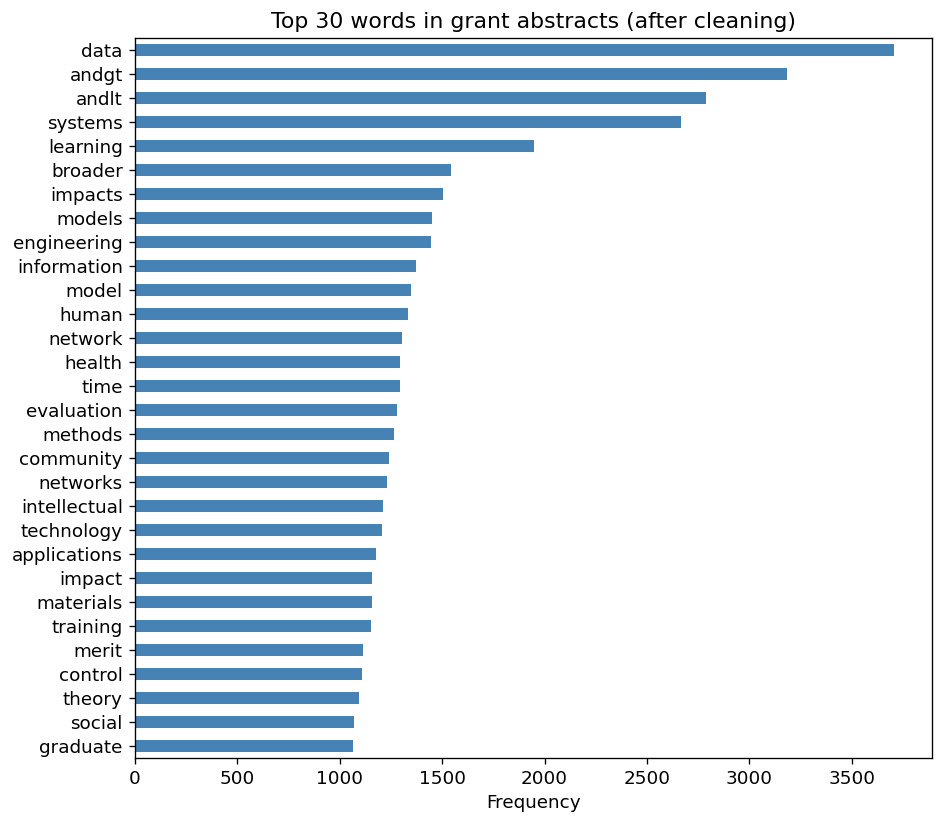

In [7]:
# Bar chart of top 30 content words
top_words = pd.Series(freq_content).head(30).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
top_words.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Frequency')
ax.set_title('Top 30 words in grant abstracts (after cleaning)')
plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()

## Method 1 — LDA

In [8]:
# Build count matrix for LDA
# min_df=5: word must appear in at least 5 documents
# max_df=0.85: skip words in more than 85% of documents
N_TOPICS = 8

count_vec = CountVectorizer(
    stop_words=all_stops,
    ngram_range=(1, 2),
    max_features=3000,
    min_df=5,
    max_df=0.85
)
count_matrix = count_vec.fit_transform(aa['clean_text'])
print(f'Vocabulary: {len(count_vec.get_feature_names_out()):,} terms')
print(f'Matrix: {count_matrix.shape}')

Vocabulary: 3,000 terms
Matrix: (2873, 3000)


In [9]:
# Fit LDA
lda = LatentDirichletAllocation(
    n_components=N_TOPICS, max_iter=25,
    learning_method='online', random_state=42, n_jobs=-1
)
lda_doc_topics = lda.fit_transform(count_matrix)
print(f'LDA done. Perplexity: {lda.perplexity(count_matrix):.1f}')

LDA done. Perplexity: 1295.4


In [10]:
# Print top 12 words per topic — read these to name your topics
def show_topics(model, vectorizer, n_words=12):
    names = vectorizer.get_feature_names_out()
    for i, topic in enumerate(model.components_):
        words = [names[j] for j in topic.argsort()[:-n_words-1:-1]]
        print(f'  Topic {i+1:2d}: {" | ".join(words)}')

print(f'LDA Topics (n={N_TOPICS}):')
print()
show_topics(lda, count_vec)

LDA Topics (n=8):

  Topic  1: data | systems | water | network | analysis | algorithms | networks | information | control | methods | techniques | applications
  Topic  2: social | health | data | public | community | information | environmental | technology | infrastructure | training | risk | policy
  Topic  3: materials | energy | power | devices | wireless | sensing | systems | applications | low | technology | integrated | magnetic
  Topic  4: learning | nsf | data | mission | evaluation | criteria | review | reflects | deemed | worthy | merit broader | statutory mission
  Topic  5: andgt | andlt | andlt andgt | andgt andlt | theory | physics | quantum | geometry | group | theoretical | representation | groups
  Topic  6: cell | cells | molecular | drug | function | protein | cancer | proteins | studies | dna | biological | tissue
  Topic  7: engineering | stem | graduate | conference | community | undergraduate | researchers | school | workshop | training | field | marine
  Topi

n= 5  perplexity=1375.0
n= 7  perplexity=1315.3
n= 8  perplexity=1297.0
n=10  perplexity=1265.4
n=12  perplexity=1241.3
n=15  perplexity=1202.5


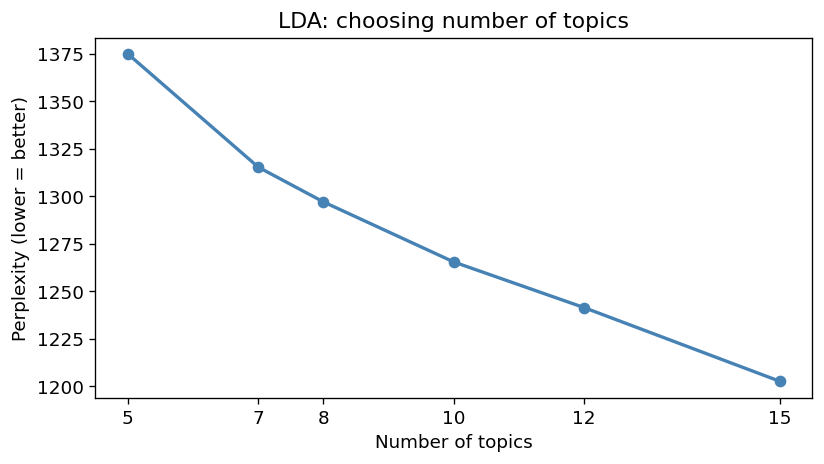

In [11]:
# Perplexity across different n_topics — look for the elbow
topic_range = [5, 7, 8, 10, 12, 15]
perplexities = []

for n in topic_range:
    m = LatentDirichletAllocation(n_components=n, max_iter=20,
                                   learning_method='online', random_state=42, n_jobs=-1)
    m.fit(count_matrix)
    p = m.perplexity(count_matrix)
    perplexities.append(p)
    print(f'n={n:2d}  perplexity={p:.1f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(topic_range, perplexities, marker='o', color='steelblue', linewidth=2)
ax.set_xlabel('Number of topics')
ax.set_ylabel('Perplexity (lower = better)')
ax.set_title('LDA: choosing number of topics')
ax.set_xticks(topic_range)
plt.tight_layout()
plt.savefig('lda_perplexity.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Assign dominant topic — fill in labels after reading the words above
aa['lda_topic'] = lda_doc_topics.argmax(axis=1)

lda_labels = {
    0: 'Topic 1 — label me',
    1: 'Topic 2 — label me',
    2: 'Topic 3 — label me',
    3: 'Topic 4 — label me',
    4: 'Topic 5 — label me',
    5: 'Topic 6 — label me',
    6: 'Topic 7 — label me',
    7: 'Topic 8 — label me',
}
aa['lda_label'] = aa['lda_topic'].map(lda_labels)

print('Grant count per LDA topic:')
print(aa['lda_label'].value_counts().to_string())

Grant count per LDA topic:
lda_label
Topic 6 — label me    543
Topic 7 — label me    398
Topic 1 — label me    395
Topic 4 — label me    395
Topic 3 — label me    357
Topic 2 — label me    306
Topic 8 — label me    269
Topic 5 — label me    210


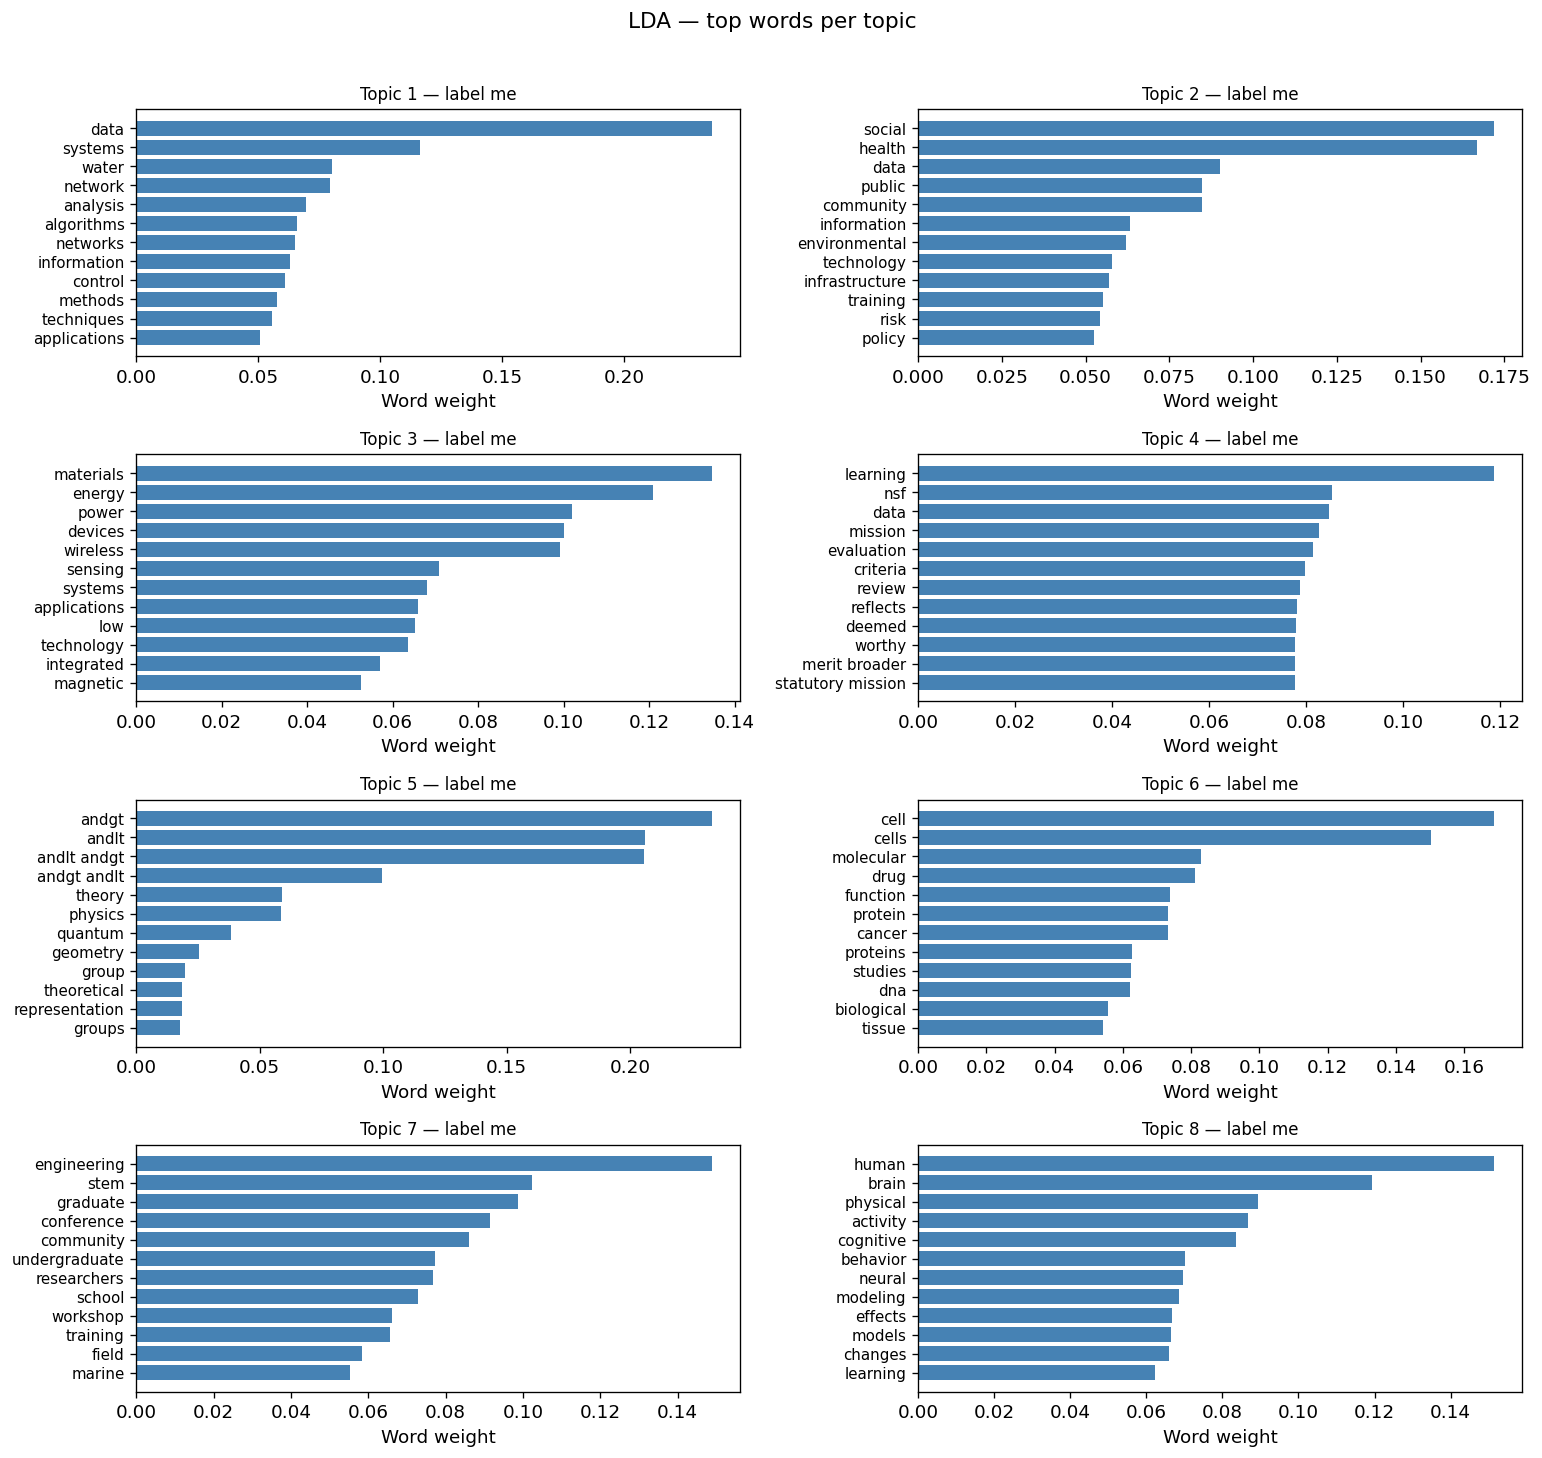

In [13]:
# Grid of top words per LDA topic
feature_names = count_vec.get_feature_names_out()
n_cols = 2
n_rows = (N_TOPICS + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, n_rows * 3))
axes = axes.flatten()

for i, topic in enumerate(lda.components_):
    top_idx   = topic.argsort()[:-13:-1]
    top_words = [feature_names[j] for j in top_idx]
    top_vals  = topic[top_idx] / topic[top_idx].sum()
    axes[i].barh(range(12), top_vals[::-1], color='steelblue')
    axes[i].set_yticks(range(12))
    axes[i].set_yticklabels(top_words[::-1], fontsize=9)
    axes[i].set_title(lda_labels.get(i, f'Topic {i+1}'), fontsize=10)
    axes[i].set_xlabel('Word weight')

for j in range(N_TOPICS, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('LDA — top words per topic', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('lda_topic_words.png', dpi=150, bbox_inches='tight')
plt.show()

Funding per LDA topic:
                    num_grants  total_M   avg_K
lda_label                                      
Topic 5 — label me         210    121.0   576.0
Topic 3 — label me         357    254.4   712.0
Topic 8 — label me         269    272.0  1011.0
Topic 4 — label me         395    322.4   816.0
Topic 7 — label me         398    322.6   811.0
Topic 2 — label me         306    426.6  1394.0
Topic 1 — label me         395    468.5  1186.0
Topic 6 — label me         543    724.5  1334.0


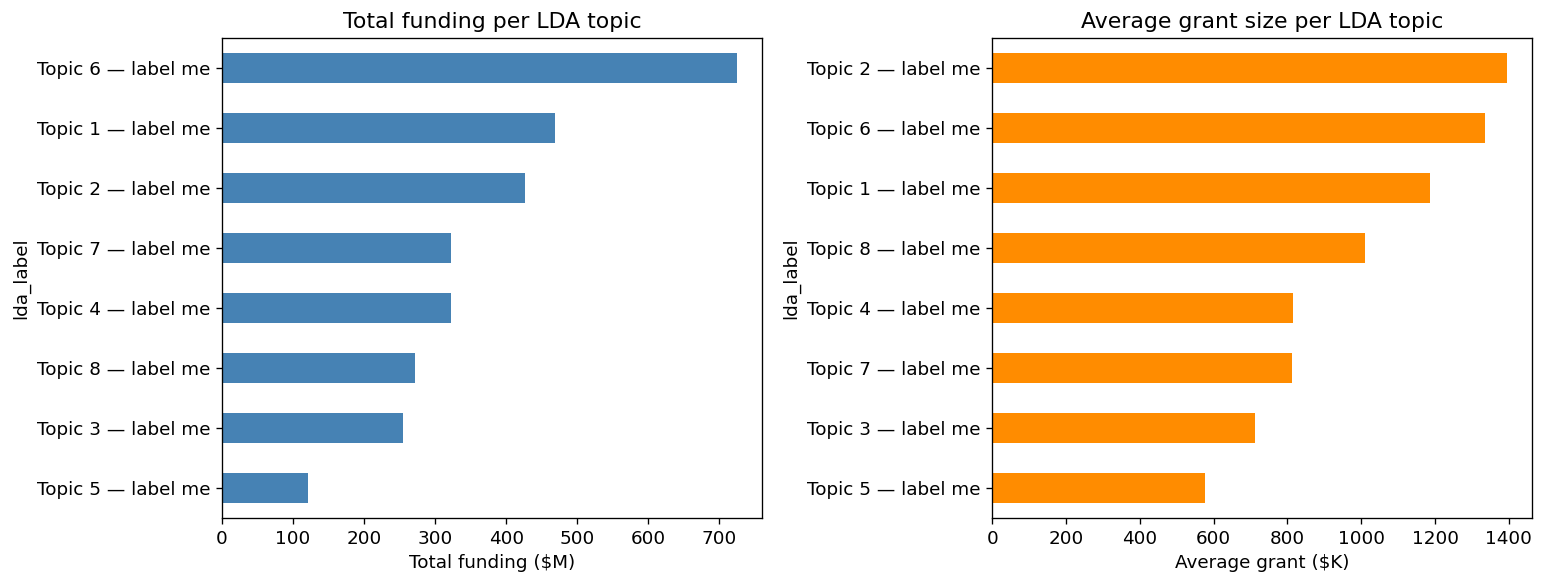

In [14]:
# Grant count and funding per LDA topic
lda_funding = (
    aa.groupby('lda_label')['Dollar Amount']
    .agg(['sum','count','mean'])
    .rename(columns={'sum':'total','count':'num_grants','mean':'avg'})
    .sort_values('total', ascending=True)
)
lda_funding['total_M'] = (lda_funding['total'] / 1e6).round(1)
lda_funding['avg_K']   = (lda_funding['avg']   / 1e3).round(0)

print('Funding per LDA topic:')
print(lda_funding[['num_grants','total_M','avg_K']].to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
lda_funding['total_M'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_xlabel('Total funding ($M)')
axes[0].set_title('Total funding per LDA topic')

lda_funding['avg_K'].sort_values().plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_xlabel('Average grant ($K)')
axes[1].set_title('Average grant size per LDA topic')

plt.tight_layout()
plt.savefig('lda_topic_funding.png', dpi=150, bbox_inches='tight')
plt.show()

## Method 2 — NMF

In [15]:
# NMF on TF-IDF — tends to give cleaner, more distinct topics than LDA
tfidf_vec = TfidfVectorizer(
    stop_words=all_stops,
    ngram_range=(1, 2),
    max_features=3000,
    min_df=5,
    max_df=0.85
)
tfidf_matrix = tfidf_vec.fit_transform(aa['clean_text'])

nmf = NMF(n_components=N_TOPICS, random_state=42, max_iter=400)
nmf_doc_topics = nmf.fit_transform(tfidf_matrix)
print('NMF done.')

NMF done.


In [16]:
# Print NMF topic words
print(f'NMF Topics (n={N_TOPICS}):')
print()
show_topics(nmf, tfidf_vec)

NMF Topics (n=8):

  Topic  1: water | health | social | environmental | public | community | communities | risk | data | coastal | climate | change
  Topic  2: andgt | andlt | andlt andgt | andgt andlt | andgt reflects | nsf | quantum | review | mission | reflects nsf | nsf statutory | mission deemed
  Topic  3: theory | geometry | algebraic | representation theory | algebras | representation | algebraic geometry | moduli | quantum | spaces | varieties | algebra
  Topic  4: cell | cells | cancer | drug | protein | materials | molecular | proteins | dna | tumor | tissue | function
  Topic  5: conference | workshop | engineering | travel | international | stem | researchers | participants | community | graduate | held | acm
  Topic  6: wireless | networks | network | power | spectrum | security | devices | energy | communication | systems | sensing | hardware
  Topic  7: physics | particle | standard model | particle physics | higgs | lhc | cms | standard | energy | group | collider | m

In [17]:
# Assign NMF topics and label
aa['nmf_topic'] = nmf_doc_topics.argmax(axis=1)

nmf_labels = {
    0: 'Topic 1 — label me',
    1: 'Topic 2 — label me',
    2: 'Topic 3 — label me',
    3: 'Topic 4 — label me',
    4: 'Topic 5 — label me',
    5: 'Topic 6 — label me',
    6: 'Topic 7 — label me',
    7: 'Topic 8 — label me',
}
aa['nmf_label'] = aa['nmf_topic'].map(nmf_labels)

print('Grant count per NMF topic:')
print(aa['nmf_label'].value_counts().to_string())

Grant count per NMF topic:
nmf_label
Topic 8 — label me    626
Topic 4 — label me    613
Topic 6 — label me    418
Topic 1 — label me    374
Topic 2 — label me    364
Topic 5 — label me    279
Topic 3 — label me    104
Topic 7 — label me     95


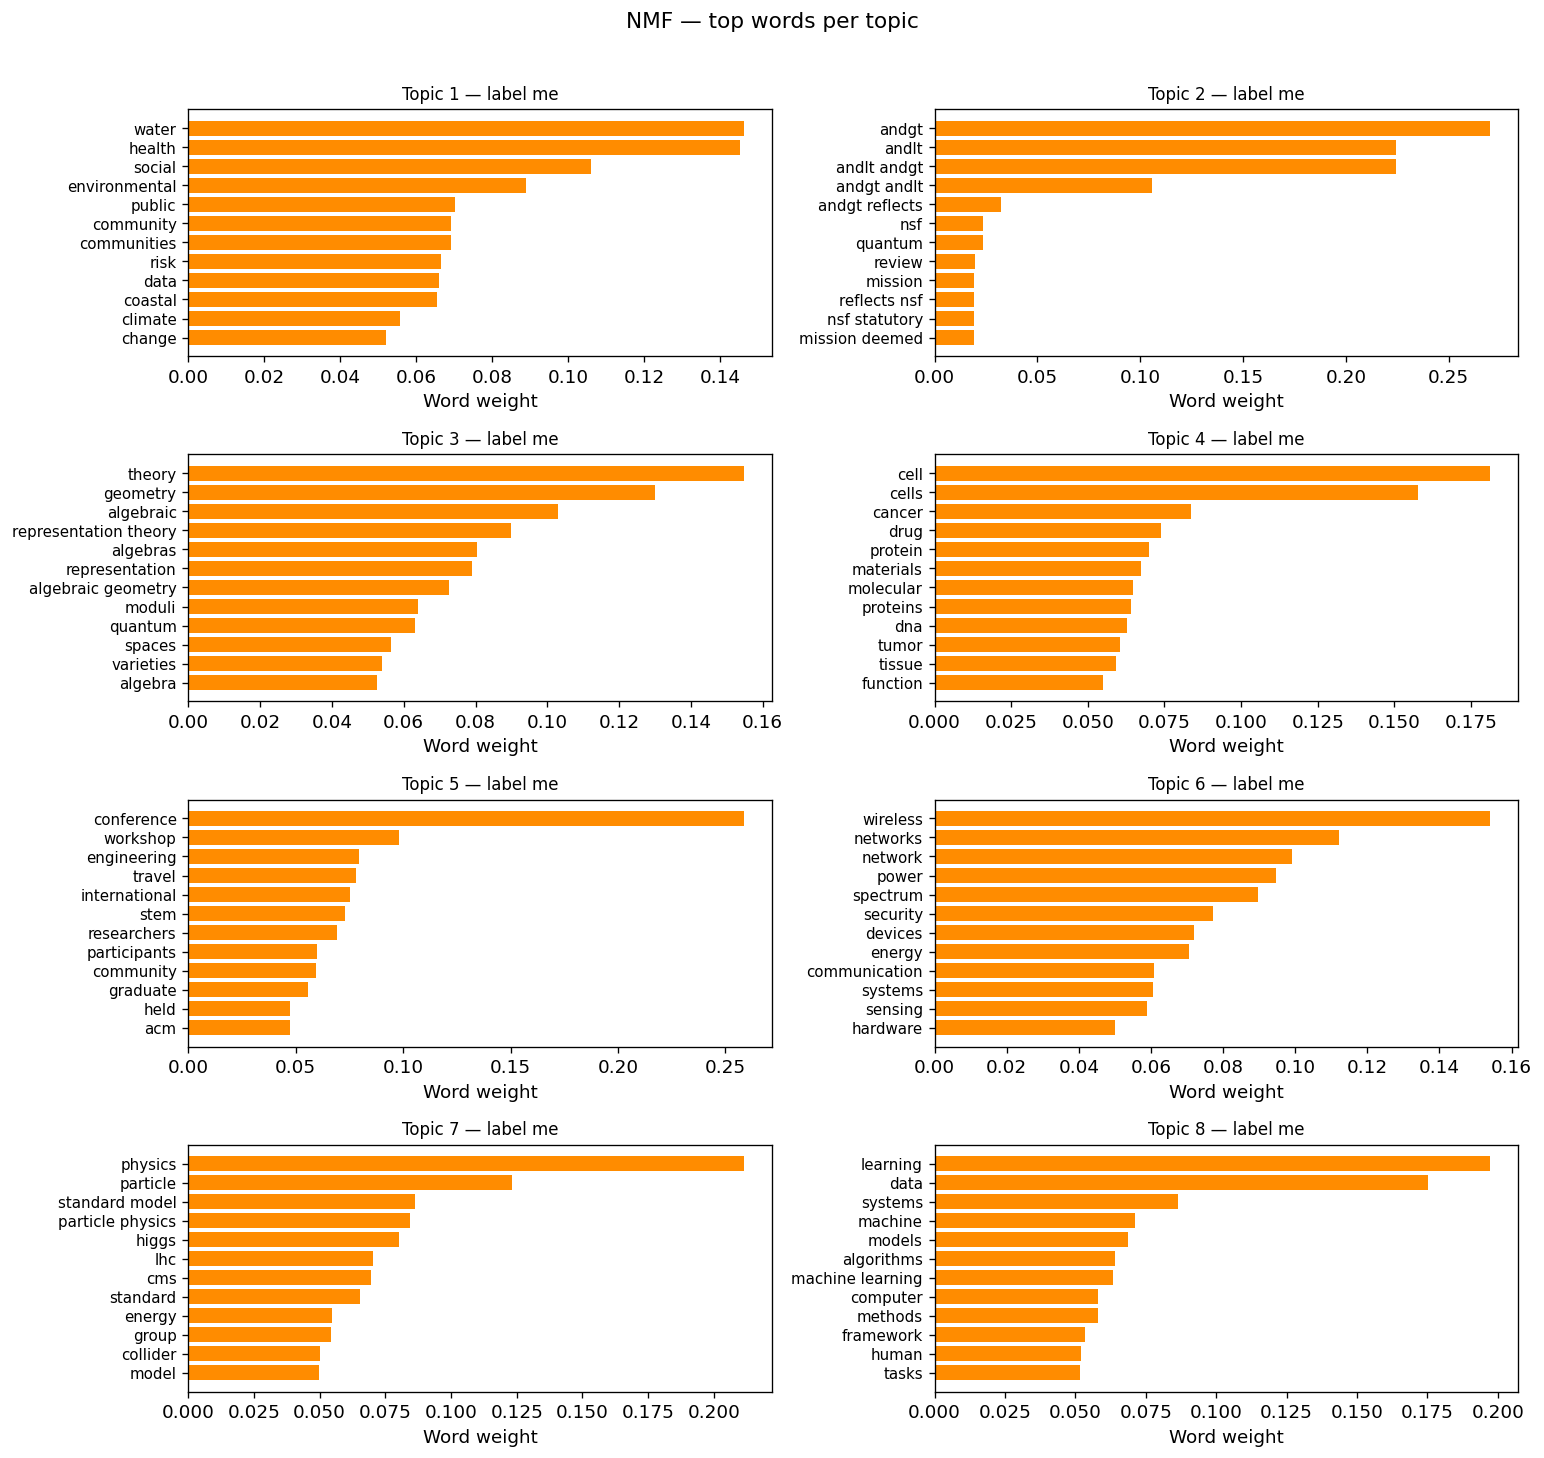

In [18]:
# NMF top words grid
feature_names_tfidf = tfidf_vec.get_feature_names_out()

fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, n_rows * 3))
axes = axes.flatten()

for i, topic in enumerate(nmf.components_):
    top_idx   = topic.argsort()[:-13:-1]
    top_words = [feature_names_tfidf[j] for j in top_idx]
    top_vals  = topic[top_idx] / topic[top_idx].sum()
    axes[i].barh(range(12), top_vals[::-1], color='darkorange')
    axes[i].set_yticks(range(12))
    axes[i].set_yticklabels(top_words[::-1], fontsize=9)
    axes[i].set_title(nmf_labels.get(i, f'Topic {i+1}'), fontsize=10)
    axes[i].set_xlabel('Word weight')

for j in range(N_TOPICS, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('NMF — top words per topic', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('nmf_topic_words.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# LDA vs NMF agreement — cross-tab
# High values on diagonal = both methods agree on that cluster
crosstab = pd.crosstab(aa['lda_topic'], aa['nmf_topic'],
                        rownames=['LDA'], colnames=['NMF'])
print('LDA vs NMF topic agreement (cross-tab):')
print(crosstab.to_string())
print()
print('Topics may be in different order across methods.')
print('Look for clusters, not perfect diagonal alignment.')

LDA vs NMF topic agreement (cross-tab):
NMF    0   1   2    3    4    5   6    7
LDA                                     
0     32  29   2    6    0  115   2  209
1    154  59   0   10   37   14   0   32
2      1  42   0   70    1  211  26    6
3      9  99   1    2   14   61   2  207
4      0  48  94    2   11    0  55    0
5     13  31   0  483    2    3   2    9
6     82  39   6   16  207   10   8   30
7     83  17   1   24    7    4   0  133

Topics may be in different order across methods.
Look for clusters, not perfect diagonal alignment.


## Method 3 — BERTopic

In [20]:
# BERTopic: understands meaning, not just word frequency
# Install: pip install bertopic sentence-transformers umap-learn hdbscan
try:
    from bertopic import BERTopic
    BERT_OK = True
    print('BERTopic ready.')
except ImportError:
    BERT_OK = False
    print('Not installed. Run: pip install bertopic sentence-transformers umap-learn hdbscan')

BERTopic ready.


In [21]:
# Fit BERTopic — use original text (not cleaned), BERT handles it
# Takes 3-5 min, downloads model (~80MB) on first run
if BERT_OK:
    docs = aa['full_text'].tolist()
    bert = BERTopic(
        embedding_model='all-MiniLM-L6-v2',
        nr_topics='auto',
        min_topic_size=15,
        verbose=True
    )
    bert_topics, _ = bert.fit_transform(docs)
    aa['bert_topic'] = bert_topics

    n_found   = bert.get_topic_info().shape[0] - 1
    n_outlier = (aa['bert_topic'] == -1).sum()
    print(f'Topics found  : {n_found}')
    print(f'Outlier docs  : {n_outlier} ({n_outlier/len(aa)*100:.1f}%)')
else:
    print('Skipping.')

2026-06-01 22:24:00,783 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 90/90 [00:11<00:00,  7.78it/s]
2026-06-01 22:24:13,826 - BERTopic - Embedding - Completed ✓
2026-06-01 22:24:13,826 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
2026-06-01 22:24:21,867 - BERTopic - Dimensionality - Completed ✓
2026-06-01 22:24:21,868 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-01 22:24:21,901 - BERTopic - Cluster - Completed ✓
2026-06-01 22:24:21,902 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-06-01 22:24:22,212 - BERTopic - Representation - Completed ✓
2026-06-01 22:24:22,212 - BERTopic - Topic reduction - Reducing number of topics
2026-06-01 22:24:22,218 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-01 22:24:22,521 - BE

Topics found  : 12
Outlier docs  : 575 (20.0%)


In [22]:
# Print BERTopic topic words
if BERT_OK:
    topic_info = bert.get_topic_info()
    print('Top BERTopic topics:')
    print(topic_info[topic_info['Topic'] != -1][['Topic','Count','Name']].head(15).to_string(index=False))
    print()
    for t in topic_info[topic_info['Topic'] != -1]['Topic'].head(12):
        words = bert.get_topic(t)
        print(f'Topic {t:2d}: {" | ".join([w for w, _ in words[:8]])}')

Top BERTopic topics:
 Topic  Count                          Name
     0   1356               0_the_and_of_to
     1    322               1_and_the_of_to
     2    178        2_and_the_of_materials
     3    112       3_the_of_physics_theory
     4     91          4_the_to_of_software
     5     57                5_of_the_in_to
     6     46            6_speech_the_of_to
     7     40 7_underwater_the_acoustic_and
     8     34   8_moduli_geometry_of_spaces
     9     27         9_fear_emotion_the_in
    10     19         10_mtdna_the_of_cells
    11     16        11_pip2_of_the_channel

Topic  0: the | and | of | to | in | will | for | this
Topic  1: and | the | of | to | for | in | project | wireless
Topic  2: and | the | of | materials | in | to | will | this
Topic  3: the | of | physics | theory | and | in | algebras | to
Topic  4: the | to | of | software | and | for | languages | is
Topic  5: of | the | in | to | and | that | is | will
Topic  6: speech | the | of | to | and | in |

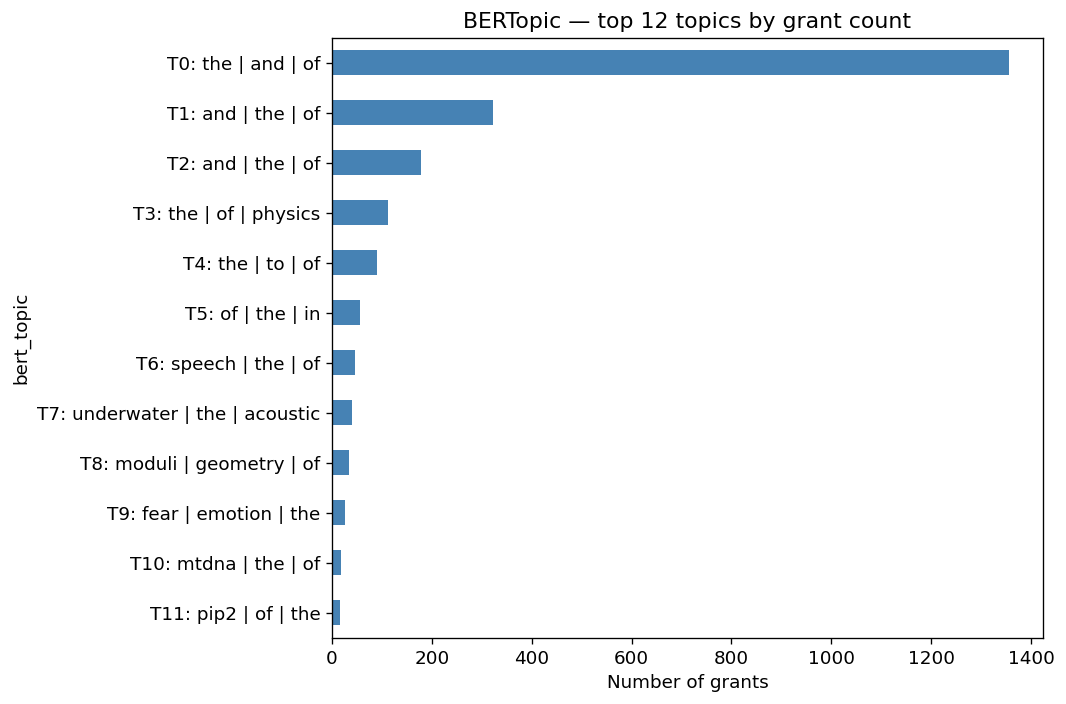

In [23]:
# BERTopic grant count bar chart
if BERT_OK:
    bert_counts = (
        aa[aa['bert_topic'] != -1]['bert_topic']
        .value_counts().head(12)
        .rename(index=lambda t: f'T{t}: ' + ' | '.join([w for w, _ in bert.get_topic(t)[:3]]))
        .sort_values()
    )
    fig, ax = plt.subplots(figsize=(9, 6))
    bert_counts.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('Number of grants')
    ax.set_title('BERTopic — top 12 topics by grant count')
    plt.tight_layout()
    plt.savefig('bertopic_counts.png', dpi=150, bbox_inches='tight')
    plt.show()

In [24]:
# BERTopic interactive HTML outputs — open in browser
if BERT_OK:
    bert.visualize_barchart(top_n_topics=12).write_html('bertopic_barchart.html')
    bert.visualize_topics().write_html('bertopic_map.html')
    bert.visualize_heatmap().write_html('bertopic_heatmap.html')
    print('Saved: bertopic_barchart.html, bertopic_map.html, bertopic_heatmap.html')

Saved: bertopic_barchart.html, bertopic_map.html, bertopic_heatmap.html


## Comparison

In [25]:
# Side-by-side LDA vs NMF words — use this to name your topics
print('LDA vs NMF — top words side by side')
print('=' * 70)
lda_names = count_vec.get_feature_names_out()
nmf_names = tfidf_vec.get_feature_names_out()

for i in range(N_TOPICS):
    lda_words = [lda_names[j] for j in lda.components_[i].argsort()[:-9:-1]]
    nmf_words = [nmf_names[j] for j in nmf.components_[i].argsort()[:-9:-1]]
    print(f'T{i+1:02d}  LDA: {" | ".join(lda_words)}')
    print(f'     NMF: {" | ".join(nmf_words)}')
    print()

LDA vs NMF — top words side by side
T01  LDA: data | systems | water | network | analysis | algorithms | networks | information
     NMF: water | health | social | environmental | public | community | communities | risk

T02  LDA: social | health | data | public | community | information | environmental | technology
     NMF: andgt | andlt | andlt andgt | andgt andlt | andgt reflects | nsf | quantum | review

T03  LDA: materials | energy | power | devices | wireless | sensing | systems | applications
     NMF: theory | geometry | algebraic | representation theory | algebras | representation | algebraic geometry | moduli

T04  LDA: learning | nsf | data | mission | evaluation | criteria | review | reflects
     NMF: cell | cells | cancer | drug | protein | materials | molecular | proteins

T05  LDA: andgt | andlt | andlt andgt | andgt andlt | theory | physics | quantum | geometry
     NMF: conference | workshop | engineering | travel | international | stem | researchers | participants



In [26]:
# Method summary
print('METHOD SUMMARY')
print('=' * 50)
print('LDA   : probabilistic, good baseline, can be noisy')
print('NMF   : cleaner topics, recommended as primary')
print('BERT  : semantic meaning, no fixed n needed, slower')
print()
print('Next step: fill in topic labels in lda_labels')
print('and nmf_labels dicts above, then re-run those cells.')

METHOD SUMMARY
LDA   : probabilistic, good baseline, can be noisy
NMF   : cleaner topics, recommended as primary
BERT  : semantic meaning, no fixed n needed, slower

Next step: fill in topic labels in lda_labels
and nmf_labels dicts above, then re-run those cells.
